# Exploratory Data Analysis

## Context
This is a **multivariate dataset** containing multiple clinical variables used for analyzing and predicting heart disease.

- Total attributes available: **76**
- Commonly used subset: **14 key features**
- Most widely used version: **Cleveland dataset**
- Primary task:  
  → Predict whether a patient has **heart disease** based on clinical measurements  
- Secondary task:  
  → Perform **exploratory analysis** to uncover patterns and insights

---

## Dataset Structure

### Key Features (14 Variables)

| Feature | Description |
|--------|------------|
| `age` | Age of the patient (years) |
| `sex` | Biological sex (Male/Female) |
| `cp` | Chest pain type *(typical angina, atypical angina, non-anginal, asymptomatic)* |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl *(True/False)* |
| `restecg` | Resting ECG results *(normal, ST-T abnormality, LV hypertrophy)* |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina *(True/False)* |
| `oldpeak` | ST depression (exercise vs rest) |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels (0–3) |
| `thal` | Thalassemia *(normal, fixed defect, reversible defect)* |
| `num` | Target variable (heart disease presence) |

---

### Additional Columns

| Feature | Description |
|--------|------------|
| `id` | Unique patient identifier |
| `origin` | Location of study |

---

## Target Variable

- `num` → Indicates **presence of heart disease**
  - `0` = No disease  
  - `1+` = Presence of disease  

---

## Use Cases

- Classification modeling (e.g., Logistic Regression, XGBoost)
- Risk prediction tools
- Clinical feature importance analysis
- Bias and fairness analysis across patient groups

---

## Data Sources

- Hungarian Institute of Cardiology (Budapest)
- University Hospital Zurich
- University Hospital Basel
- Cleveland Clinic Foundation

---

## Key References

- Detrano et al. (1989) – *American Journal of Cardiology*
- Aha & Kibler – Instance-based prediction methods
- Gennari et al. (1989) – Concept formation models

---

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('../data/raw/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [2]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


Turn our multi-class variable into a binary: Non-diseased vs Diseased

In [6]:
df["target"] = (df["num"] > 0).astype(int)
df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

# The following code will be some EDA, visualizing variables, and gaining some general insights before model building.

# Age vs Heart Disease Presence

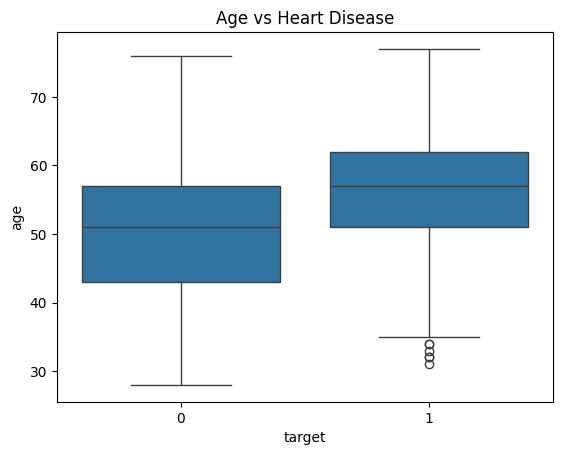

In [11]:
sns.boxplot(data=df, x="target", y="age")
plt.title("Age vs Heart Disease")
plt.show()

In [12]:
df.groupby("target")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,411.0,50.547445,9.433700,28.0,43.0,51.0,57.0,76.0
1,509.0,55.903733,8.718959,31.0,51.0,57.0,62.0,77.0


We can see that those with heart disease have a higher median age than those without, thus, it is reasonable to include that a higher age is associated with heart disease presence, with few outliers just above the 30 range. However, the age ranges still overlap, and thus more age is a mediocre predictor, but more analysis is needed.

# Heart Rate vs Diseased State


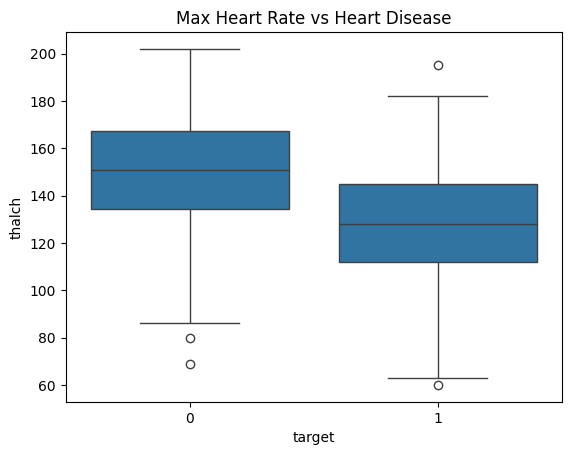

In [14]:
sns.boxplot(data=df, x="target", y="thalch")
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

In [15]:
df.groupby("target")["thalch"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,391.0,148.800512,23.608692,69.0,134.5,151.0,167.5,202.0
1,474.0,128.261603,24.024193,60.0,112.0,128.0,145.0,195.0


It can be noted that diseased patients have lower maximum heart rates, with 75% being below the median of healthy patients. Maximum heart rate is likely a strong predictor.

## ST Depression (vs rest baseline) in Healthy vs Diseased patients

<Axes: xlabel='target', ylabel='oldpeak'>

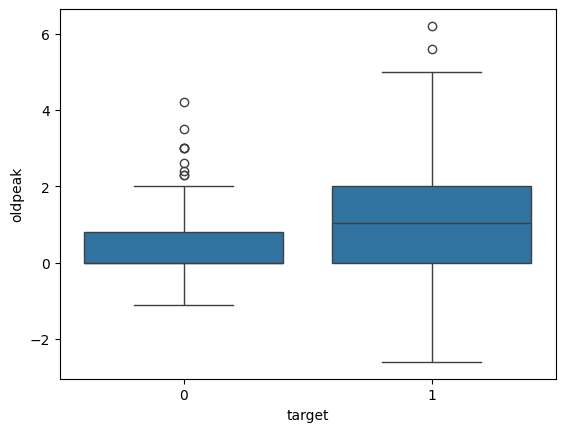

In [16]:
sns.boxplot(data=df, x="target", y="oldpeak")

In [17]:
df.groupby("target")["oldpeak"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,390.0,0.418205,0.715636,-1.1,0.0,0.00,0.8,4.2
1,468.0,1.262607,1.197424,-2.6,0.0,1.05,2.0,6.2


It can be seen that diseased patients have substantially higher ST depression. The upper range difference shows that the typical disease patient has more ST dperession than most healthy patients. HOWEVER, the Q1 for both cases is 0.0, meaning many diseased patients have 0 depression. Therefore oldpeak is a strong predictor, but it is not perfect.

## Comparing Heart Rate and ST Depression

Visualize if there are clusters or coorelations within the disease/healthy groups

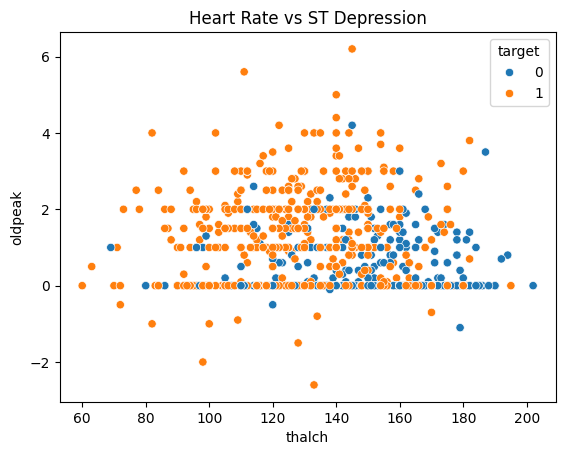

In [19]:
sns.scatterplot(data=df, x="thalch", y="oldpeak", hue="target")
plt.title("Heart Rate vs ST Depression")
plt.show()

As it can be seen, there are no distinct groups. While some diseased patients have lower heart rates, the groups heavily overlap one another. This will lead us into our analysis with models